# 01. Thu Thập và Chuẩn Hóa Dữ Liệu Chất Lượng Không Khí & Khí Tượng Hà Nội

> **Khóa học:** INFO3020 – Nhập môn Khoa học Dữ liệu (CMC University)  
> **Repository:** `doctor-cato/air-pollution-analysis`  
> **Milestone 1:** Triển khai Issue #3, #4 & #19 – Pipeline thu thập và chuẩn hóa dữ liệu ô nhiễm không khí & khí tượng mặt đất Hà Nội.  
> **Quyết định rà soát nguồn dữ liệu (PR #24 & Issue #3/#4 Sync):**  
> - **Thu hồi & loại bỏ hoàn toàn OpenAQ `location_id=2178`** (Del Norte, Albuquerque, NM, Hoa Kỳ).  
> - **Xác thực trạm chuẩn quốc gia hiện hành:** OpenAQ `location_id=4946811` (Trạm 556 Nguyễn Văn Cừ, Long Biên, Hà Nội - NCEM/VEA), mã canonical: `VN001_HANOI_556_NGUYEN_VAN_CU`.  
> - **Nguồn khí tượng bề mặt (PRIMARY):** ECMWF ERA5 Reanalysis từ Open-Meteo API. Tọa độ truy vấn $21.0285^\circ\text{N}, 105.8542^\circ\text{E}$ (tâm lõi Hà Nội); API trả về điểm lưới $21.0545^\circ\text{N}, 105.8985^\circ\text{E}$ – cách trạm 556 Nguyễn Văn Cừ **1.71 km**. Nguồn dự phòng NOAA ISD 48820 **không được kích hoạt** vì Open-Meteo đã đáp ứng đầy đủ yêu cầu (Issue #19 §12.2).  
> - **Đồng bộ hóa thời gian động (Dynamic Temporal Synchronization):** Cửa sổ truy vấn khí tượng Open-Meteo được suy diễn động từ chuỗi thời gian canonical `Asia/Ho_Chi_Minh` của trạm 4946811 – **không có bất kỳ khung thời gian lịch sử cố định nào** trong mã nguồn.  
> - **Kiểm định chất lượng khí tượng toàn trình (Issue #4 Validation):** `validate_weather_canonical()` kiểm tra schema, múi giờ `Asia/Ho_Chi_Minh`, trùng lặp, tính đơn điệu, tính liên tục 1 giờ, giới hạn vật lý và tỷ lệ khuyết thiếu.  
> - **Bảo toàn dữ liệu thô:** payload nguồn được ghi **nguyên trạng** vào `data/raw/` (không chỉnh sửa thủ công, không chuyển đổi giá trị trước khi lưu); mọi biến đổi diễn ra ở lớp cleaning/canonical. Mã băm SHA-256 của tệp thô được ghi lại trong `data/raw/metadata.json` để kiểm chứng tính toàn vẹn. Tệp thô **không được commit vào Git** (xem `.gitignore`), được tái tạo lại bằng `run_collection_pipeline()`.  
> - **Nguồn chuẩn lịch sử & Trạng thái AirNowDOSAdapter:** Class `AirNowDOSAdapter` (`VN002_HANOI_US_EMBASSY`, BAM-1020 FEM) đã được hiện thực hóa đầy đủ. Trạng thái nạp thực tế: `implemented` / `not_executed_pending_raw_input` (do tệp lịch sử DOS yêu cầu tài khoản tổ chức AirNow-Tech / State Dept, tuyệt đối không tạo dữ liệu giả lập).  
> - **Phân định dải thời gian:** Phân biệt rành mạch `requested_study_window` (tham số truy vấn) và `actual_source_coverage` (tính trực tiếp từ `min()` và `max()` timestamp thực tế của DataFrame).

In [1]:
import sys
from pathlib import Path
import json
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm đường dẫn src vào sys.path
sys.path.insert(0, str(Path("..").resolve()))
from src.data_collection import (
    HANOI_BBOX,
    HANOI_OPENAQ_LOCATION_ID,
    DISQUALIFIED_OPENAQ_LOCATION_ID,
    STATION_OPENAQ_HANOI,
    STATION_AIRNOW_HANOI,
    STATION_WEATHER_ERA5,
    WEATHER_CANONICAL_COLUMNS,
    WEATHER_PHYSICAL_BOUNDS,
    WEATHER_PIPELINE_MAX_MISSING_PCT,
    OpenAQAdapter,
    OpenMeteoAdapter,
    AirNowDOSAdapter,
    clean_air_quality_values,
    clean_weather_values,
    filter_hanoi_bounds,
    assert_canonical_within_hanoi,
    validate_canonical_uniqueness,
    validate_weather_canonical,
    resolve_station_metadata,
    compute_file_sha256,
    run_collection_pipeline,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10
sns.set_theme(style="whitegrid")
print("Đã thiết lập môi trường và nạp các module từ src/data_collection.py thành công!")

Đã thiết lập môi trường và nạp các module từ src/data_collection.py thành công!


## 1. Thu Thập Dữ Liệu Thô (Source Ingestion)

Tiến hành thu thập dữ liệu thô nguyên bản từ các nguồn đã được thẩm định chính thức:
1. **OpenAQ S3 Public Archive (`locationid=4946811`):** Trạm quan trắc chuẩn quốc gia 556 Nguyễn Văn Cừ, Long Biên, Hà Nội. Toàn bộ 352 tệp CSV.gz được tải và lưu nguyên trạng vào `data/raw/openaq_raw_4946811.parquet`.
2. **AirNow DOS Adapter Status Check:** Kiểm tra trạng thái tệp AirNow trên đĩa để kích hoạt adapter hoặc ghi nhận trạng thái chờ tệp thô hợp lệ mà không tạo dữ liệu giả.
3. **Open-Meteo ERA5 Reanalysis** được thu thập ở Mục 4, **sau khi** chuẩn hóa chuỗi chất lượng không khí — vì dải thời gian truy vấn khí tượng bắt buộc phải suy diễn động từ chuỗi thời gian canonical thực tế của ô nhiễm.

In [2]:
openaq_adapter = OpenAQAdapter(
    location_id=HANOI_OPENAQ_LOCATION_ID,
    raw_dir=Path("../data/raw"),
    interim_dir=Path("../data/interim"),
)
weather_adapter = OpenMeteoAdapter(
    raw_dir=Path("../data/raw"),
    interim_dir=Path("../data/interim"),
)
airnow_adapter = AirNowDOSAdapter(
    raw_dir=Path("../data/raw"),
    interim_dir=Path("../data/interim"),
)

# 1. Nạp/thu thập dữ liệu thô OpenAQ trạm 4946811
df_openaq_raw, openaq_raw_path = openaq_adapter.fetch_raw_data()
openaq_sha256 = compute_file_sha256(openaq_raw_path)
print(f"OpenAQ Raw Path: {openaq_raw_path}")
print(f"   Số bản ghi thô: {len(df_openaq_raw):,} dòng | Số cột: {len(df_openaq_raw.columns)}")
print(f"   Mã băm SHA-256: {openaq_sha256}")

# 2. Kiểm tra trạng thái thực tế của AirNow DOS Historical Input
print(f"\nAirNow DOS Adapter Check:")
print(f"   Mã trạm: {airnow_adapter.station_id} ({airnow_adapter.location_name})")
print(f"   Tệp cấu hình: {airnow_adapter.csv_path}")
if airnow_adapter.csv_path.exists() and airnow_adapter.csv_path.stat().st_size > 0:
    print("   Trạng thái: Có tệp thô trên đĩa -> Đã sẵn sàng nạp.")
else:
    print("   Trạng thái: Chưa có tệp thô trên đĩa (Pending raw input từ AirNow-Tech / State Dept).")
    print("   Ghi nhận: Adapter đã hiện thực hóa; không tạo dữ liệu giả lập (tuân thủ liêm chính học thuật).")

2026-09-29 19:16:17,800 [INFO] Tệp thô OpenAQ đã tồn tại tại ..\data\raw\openaq_raw_4946811.parquet. Đang nạp lại nguyên trạng (không tải lại)...


OpenAQ Raw Path: ..\data\raw\openaq_raw_4946811.parquet
   Số bản ghi thô: 349,463 dòng | Số cột: 9
   Mã băm SHA-256: 4168735570d16f80df7136e93b8da96bbb03ed5631c57ca8ffea6f09d92ae60f

AirNow DOS Adapter Check:
   Mã trạm: VN002_HANOI_US_EMBASSY (US Diplomatic Post: Hanoi)
   Tệp cấu hình: ..\data\raw\airnow_hanoi_2023.csv
   Trạng thái: Chưa có tệp thô trên đĩa (Pending raw input từ AirNow-Tech / State Dept).
   Ghi nhận: Adapter đã hiện thực hóa; không tạo dữ liệu giả lập (tuân thủ liêm chính học thuật).


## 2. Kiểm Tra Cấu Trúc Dữ Liệu Thô (Raw Profiling)

Khảo sát các thông số quan trắc có trong tệp thô, tọa độ ghi nhận và khoảng thời gian đo thực tế (*Actual Source Coverage*).

In [3]:
print("=== THỐNG KÊ THÔNG SỐ QUAN TRẮC TRẠM 4946811 ===")
print(df_openaq_raw["parameter"].value_counts())

print("\n=== TỌA ĐỘ VÀ ĐỊA DANH GHI NHẬN TRONG TỆP THÔ ===")
print(f"Location Name: {df_openaq_raw['location'].unique()}")
print(f"Latitude     : {df_openaq_raw['lat'].unique()}")
print(f"Longitude    : {df_openaq_raw['lon'].unique()}")

print("\n=== ĐỘ BAO PHỦ THỜI GIAN THỰC TẾ (ACTUAL SOURCE COVERAGE) ===")
print(f"Mốc bắt đầu  : {df_openaq_raw['datetime'].min()}")
print(f"Mốc kết thúc : {df_openaq_raw['datetime'].max()}")

df_openaq_raw.head()

=== THỐNG KÊ THÔNG SỐ QUAN TRẮC TRẠM 4946811 ===


parameter
pm10    78305
pm25    77155
o3      70949
so2     59566
co      31968
no2     31520
Name: count, dtype: int64

=== TỌA ĐỘ VÀ ĐỊA DANH GHI NHẬN TRONG TỆP THÔ ===
Location Name: ['556 Nguyễn Văn Cừ-4916744']
Latitude     : [21.0491]
Longitude    : [105.8831]

=== ĐỘ BAO PHỦ THỜI GIAN THỰC TẾ (ACTUAL SOURCE COVERAGE) ===
Mốc bắt đầu  : 2025-07-03T22:40:00+07:00
Mốc kết thúc : 2026-07-15T17:05:00+07:00


,location_id,sensors_id,location,datetime,lat,lon,parameter,units,value
0,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T22:40:00+07:00,21.0491,105.8831,pm10,µg/m³,64.44
1,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T22:45:00+07:00,21.0491,105.8831,pm10,µg/m³,63.73
2,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T22:50:00+07:00,21.0491,105.8831,pm10,µg/m³,65.89
3,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T23:00:00+07:00,21.0491,105.8831,pm10,µg/m³,64.47
4,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T23:05:00+07:00,21.0491,105.8831,pm10,µg/m³,64.07


## 3. Lọc Địa Lý Không Gian (Geographic Filtering)

Theo quy định bắt buộc của đồ án và phản hồi từ Reviewer PR #24:
- Thực thi hàm `filter_hanoi_bounds()` kiểm tra từng bản ghi với Bounding Box Hà Nội $[20.50, 21.60]^\circ\text{N}, [105.30, 106.10]^\circ\text{E}$.
- Bước lọc phải diễn ra **trước** quá trình canonicalization.
- Minh chứng cơ chế lọc hoạt động chính xác bằng cách thử nghiệm với tọa độ của trạm Albuquerque (2178) bị loại bỏ.

In [4]:
# 1. Lọc dữ liệu thực tế trạm 4946811
df_openaq_filtered, geo_stats = filter_hanoi_bounds(df_openaq_raw)
print("Kết quả lọc không gian trạm OpenAQ 4946811:")
print(json.dumps(geo_stats, indent=2, ensure_ascii=False))

# 2. Thử nghiệm cơ chế lọc loại bỏ với tọa độ ngoại lai (Albuquerque 2178)
df_synthetic_check = pd.DataFrame({
    "location": ["556 Nguyễn Văn Cừ (Hanoi)", "Del Norte (Albuquerque - 2178)"],
    "lat": [21.0491, 35.1353],
    "lon": [105.8831, -106.584702],
})
df_check_filtered, check_stats = filter_hanoi_bounds(df_synthetic_check)
print("\nKiểm chứng cơ chế loại bỏ tọa độ ngoài Hà Nội:")
print(f"Số bản ghi thô: {check_stats['raw_records']}")
print(f"Số bản ghi bị loại: {check_stats['filtered_out_records']} (Tọa độ Albuquerque bị lọc bỏ 100%)")
print(f"Số bản ghi giữ lại: {check_stats['retained_records']} (Chỉ giữ lại trạm Hà Nội)")
assert check_stats["filtered_out_records"] == 1, "Cơ chế lọc phải loại bỏ chính xác tọa độ ngoài Hà Nội!" 

2026-09-29 19:16:18,152 [INFO] Geographic Filtering: 100% bản ghi (349463/349463) nằm trong Bounding Box Hà Nội.


2026-09-29 19:16:18,156 [WARNING] Geographic Filtering: Đã loại bỏ 1/2 bản ghi ngoài Bounding Box Hà Nội!


Kết quả lọc không gian trạm OpenAQ 4946811:
{
  "raw_records": 349463,
  "filtered_out_records": 0,
  "retained_records": 349463,
  "bounding_box": {
    "lat_min": 20.5,
    "lat_max": 21.6,
    "lon_min": 105.3,
    "lon_max": 106.1
  },
  "all_within_bounds": true,
  "retained_pct": 100.0
}

Kiểm chứng cơ chế loại bỏ tọa độ ngoài Hà Nội:
Số bản ghi thô: 2
Số bản ghi bị loại: 1 (Tọa độ Albuquerque bị lọc bỏ 100%)
Số bản ghi giữ lại: 1 (Chỉ giữ lại trạm Hà Nội)


## 4. Chuẩn Hóa Schema & Xử Lý Giá Trị Dị Thường (Normalization)

Quy tắc xử lý chất lượng dữ liệu:
- Chuyển đổi mã lỗi ngụy trang (`-999`, `-9999`) $\to$ `NaN`.
- Giá trị âm phi vật lý và giá trị vi phạm giới hạn vật lý $\to$ `NaN` (được **đếm minh bạch** qua `summarize_weather_cleaning()`).
- Giá trị bằng $0.0$ là quan trắc hợp lệ $\to$ **giữ nguyên $0.0$** (tuyệt đối không `fillna(0)` để thay thế missing).
- Tổng hợp chuỗi telemetry dưới giờ thành trung bình theo giờ (*Hourly Aggregation*).
- Kiểm tra tính đúng đắn của logic chuẩn hóa trên mẫu dữ liệu AirNowDOSAdapter.
- **Dải thời gian khí tượng được suy diễn động** từ chuỗi canonical `Asia/Ho_Chi_Minh` của ô nhiễm rồi mới truy vấn Open-Meteo — không dùng khung thời gian cố định.

In [5]:
df_air_canonical = openaq_adapter.to_canonical(df_openaq_raw)

# Dẫn xuất ĐỘNG cửa sổ truy vấn khí tượng từ chuỗi thời gian canonical thực tế của ô nhiễm.
# Đây là cùng quy tắc mà run_collection_pipeline() sử dụng — không có khung thời gian
# lịch sử cố định nào được áp đặt.
weather_query_start = df_air_canonical["timestamp"].min().strftime("%Y-%m-%d")
weather_query_end = df_air_canonical["timestamp"].max().strftime("%Y-%m-%d")
print(f"\nCửa sổ truy vấn khí tượng đồng bộ động: {weather_query_start} -> {weather_query_end}")

# Nạp/thu thập dữ liệu thô Open-Meteo ERA5 theo cửa sổ đồng bộ động vừa suy diễn
weather_raw_json, weather_raw_path = weather_adapter.fetch_raw_data(
    start_date=weather_query_start, end_date=weather_query_end
)
weather_sha256 = compute_file_sha256(weather_raw_path)
num_weather_hours = len(weather_raw_json.get("hourly", {}).get("time", []))
print(f"\nOpen-Meteo Raw Path: {weather_raw_path}")
print(f"   Số mốc giờ thô: {num_weather_hours:,} giờ")
print(f"   Mã băm SHA-256: {weather_sha256}")
print(f"   Điểm lưới ERA5 trả về: ({weather_raw_json.get('latitude')}, {weather_raw_json.get('longitude')}), "
      f"độ cao {weather_raw_json.get('elevation')} m")

# Kiểm chứng logic chuẩn hóa của AirNowDOSAdapter bằng tệp tạm (in-memory verification)
sample_csv = (
    "Site, Parameter, Date (LST), Year, Month, Day, Hour, Value, Unit, Duration, QC Name\n"
    "Hanoi, PM2.5, 2023-01-01 01:00, 2023, 1, 1, 1, 35.5, UG/M3, 1 Hr, Valid\n"
    "Hanoi, PM2.5, 2023-01-01 02:00, 2023, 1, 1, 2, -999, UG/M3, 1 Hr, Missing\n"
    "Hanoi, PM2.5, 2023-01-01 03:00, 2023, 1, 1, 3, 0.0, UG/M3, 1 Hr, Valid\n"
)
with tempfile.NamedTemporaryFile("w", delete=False, suffix=".csv") as tmp:
    tmp.write(sample_csv)
    tmp_path = tmp.name

try:
    sample_adapter = AirNowDOSAdapter(csv_path=tmp_path)
    df_sample_canonical = sample_adapter.load_and_canonicalize()
    print("\nKiểm chứng logic AirNowDOSAdapter thành công:")
    print(f"   - Giá trị hợp lệ 35.5 giữ nguyên: {df_sample_canonical['pm25'].iloc[0] == 35.5}")
    print(f"   - Mã lỗi -999 chuyển thành NaN   : {np.isnan(df_sample_canonical['pm25'].iloc[1])}")
    print(f"   - Giá trị hợp lệ 0.0 giữ nguyên  : {df_sample_canonical['pm25'].iloc[2] == 0.0}")
finally:
    Path(tmp_path).unlink(missing_ok=True)

print(f"\nChuẩn hóa OpenAQ thành công: {len(df_air_canonical):,} mốc giờ.")
print(f"   Dải thời gian thực tế: {df_air_canonical['timestamp'].min()} -> {df_air_canonical['timestamp'].max()}")
print(f"   Trạm định danh       : {df_air_canonical['station_id'].iloc[0]} ({df_air_canonical['location'].iloc[0]})")

df_weather_canonical = weather_adapter.to_canonical(weather_raw_json)
print(f"\nChuẩn hóa Weather ERA5 thành công: {len(df_weather_canonical):,} mốc giờ.")
print(f"   Dải thời gian thực tế: {df_weather_canonical['timestamp'].min()} -> {df_weather_canonical['timestamp'].max()}")
print(f"   Múi giờ canonical     : {df_weather_canonical['timestamp'].dt.tz}")
print("\nThống kê lớp cleaning (minh bạch, không âm thầm loại bỏ giá trị):")
print(pd.DataFrame(df_weather_canonical.attrs["weather_cleaning"]).T.to_string())

2026-09-29 19:16:18,206 [INFO] Geographic Filtering: 100% bản ghi (349463/349463) nằm trong Bounding Box Hà Nội.


2026-09-29 19:16:19,400 [INFO] Tệp thô Open-Meteo đã tồn tại tại ..\data\raw\open_meteo_raw_2025-07-03_2026-07-15.json. Đang nạp lại nguyên trạng (không gọi lại API) để bảo toàn dữ liệu thô đã lưu.



Cửa sổ truy vấn khí tượng đồng bộ động: 2025-07-03 -> 2026-07-15

Open-Meteo Raw Path: ..\data\raw\open_meteo_raw_2025-07-03_2026-07-15.json
   Số mốc giờ thô: 9,072 giờ
   Mã băm SHA-256: 59bfececa2dc658c15898df082a19566fce7019048ec8236b55dc731f45bc79c
   Điểm lưới ERA5 trả về: (21.05448, 105.898476), độ cao 19.0 m

Kiểm chứng logic AirNowDOSAdapter thành công:
   - Giá trị hợp lệ 35.5 giữ nguyên: True
   - Mã lỗi -999 chuyển thành NaN   : True
   - Giá trị hợp lệ 0.0 giữ nguyên  : True

Chuẩn hóa OpenAQ thành công: 8,022 mốc giờ.
   Dải thời gian thực tế: 2025-07-03 22:00:00+07:00 -> 2026-07-15 17:00:00+07:00
   Trạm định danh       : VN001_HANOI_556_NGUYEN_VAN_CU (556 Nguyễn Văn Cừ)

Chuẩn hóa Weather ERA5 thành công: 9,072 mốc giờ.
   Dải thời gian thực tế: 2025-07-03 00:00:00+07:00 -> 2026-07-15 23:00:00+07:00
   Múi giờ canonical     : Asia/Ho_Chi_Minh

Thống kê lớp cleaning (minh bạch, không âm thầm loại bỏ giá trị):
                   disguised_missing  out_of_bounds  unparsea

## 5. Kiểm Định Chất Lượng Toàn Trình (Validation & Integrity Assertions)

1. Kiểm tra tính duy nhất của khóa quan trắc `(station_id, timestamp)`.
2. Assertion đảm bảo 100% bản ghi canonical nằm trong Bounding Box Hà Nội.
3. Kiểm định chất lượng toàn diện chuỗi khí tượng (Issue #4 Validation): schema canonical, múi giờ `Asia/Ho_Chi_Minh`, tính liên tục chuỗi 1 giờ, dải giá trị 6 biến trong giới hạn vật lý khí hậu Hà Nội, và tỷ lệ khuyết thiếu.
4. Đánh giá tỷ lệ thiếu tự nhiên và phân bố nồng độ bụi.
5. Kiểm tra giao thoa thời gian (Temporal Overlap) giữa ô nhiễm và khí tượng, đồng thời phát hiện row explosion.

In [6]:
# 1. Kiểm tra tính duy nhất
validate_canonical_uniqueness(df_air_canonical, key_cols=["station_id", "timestamp"])
validate_canonical_uniqueness(df_weather_canonical, key_cols=["timestamp"])
print("Assertion 1: Khóa quan trắc duy nhất, không có trùng lặp.")

# 2. Assertion 100% trong Bounding Box Hà Nội
assert_canonical_within_hanoi(df_air_canonical)
print("Assertion 2: 100% bản ghi canonical nằm trong Bounding Box Hà Nội.")

# 3. Kiểm định chất lượng toàn diện chuỗi khí tượng chuẩn hóa (Issue #4 Validation)
# Dùng cùng ngượng nghiêm ngặt mà run_collection_pipeline() áp dụng (0% khuyết thiếu).
weather_validation = validate_weather_canonical(
    df_weather_canonical, max_missing_pct=WEATHER_PIPELINE_MAX_MISSING_PCT
)
print("\n=== KIỂM ĐỊNH CHẤT LƯỢNG KHÍ TƯỢNG (ISSUE #4 VALIDATION) ===")
print(f"Trạng thái kiểm định        : {weather_validation['validation_status'].upper()}")
print(f"Tổng số mốc giờ khí tượng   : {weather_validation['total_records']:,} giờ")
print(f"Dải thời gian khí tượng     : {weather_validation['min_timestamp']} -> {weather_validation['max_timestamp']}")
print(f"Múi giờ canonical           : {weather_validation['timezone']} (UTC+{weather_validation['utc_offset_hours']:g})")
continuity_note = 'LIÊN TỤC 100%' if weather_validation['is_continuous_hourly'] else f"GIÁN ĐOẠN ({weather_validation['gap_count']} khoảng)"
print(f"Tính liên tục chuỗi 1 giờ   : {continuity_note}")
print(f"Tỷ lệ khuyết thiếu tối đa   : {weather_validation['max_missing_pct']}% (ngưỡng {weather_validation['missing_pct_threshold']})")
print(f"Giá trị bị lớp cleaning loại bỏ: {weather_validation['cleaning_totals']}")
if weather_validation["warnings"]:
    print("Cảnh báo kiểm định:")
    for w in weather_validation["warnings"]:
        print(f"   - {w}")
print("\nThống kê phân phối và kiểm toán dải vật lý 6 biến khí tượng ERA5:")
df_weather_summary = pd.DataFrame(weather_validation["variables_summary"]).T[
    ["count", "missing", "missing_pct", "min", "mean", "max", "unit"]
]
print(df_weather_summary.to_string())

# 4. Đánh giá tỷ lệ thiếu và thống kê mô tả chất lượng không khí
missing_pm25 = df_air_canonical["pm25"].isna().sum()
missing_rate_pm25 = df_air_canonical["pm25"].isna().mean() * 100
missing_pm10 = df_air_canonical["pm10"].isna().sum()
missing_rate_pm10 = df_air_canonical["pm10"].isna().mean() * 100

print(f"\nTỷ lệ thiếu PM2.5: {missing_pm25:,}/{len(df_air_canonical):,} ({missing_rate_pm25:.2f}%)")
print(f"Tỷ lệ thiếu PM10 : {missing_pm10:,}/{len(df_air_canonical):,} ({missing_rate_pm10:.2f}%)")
print("\nThống kê phân phối PM2.5 thực đo (µg/m³):")
print(df_air_canonical["pm25"].describe())

# 5. Kiểm tra giao thoa thời gian (Temporal Overlap) giữa Air Quality và Weather
df_overlap = pd.merge(df_air_canonical, df_weather_canonical, on="timestamp", how="inner")
coverage_pct = len(df_overlap) / len(df_air_canonical) * 100
print("\n=== KIỂM TRA GIAO THOA THỜI GIAN (TEMPORAL OVERLAP) ===")
print(f"Số bản ghi giao thoa: {len(df_overlap):,} mốc giờ")
print(f"Mốc bắt đầu giao thoa: {df_overlap['timestamp'].min()}")
print(f"Mốc kết thúc giao thoa: {df_overlap['timestamp'].max()}")
print(f"Độ bao phủ chất lượng không khí: {coverage_pct:.2f}%")
assert len(df_overlap) > 0, "Tập giao thoa thời gian giữa chất lượng không khí và khí tượng không được rỗng!"
assert len(df_overlap) <= len(df_air_canonical), "Row explosion detected!"
print(f"Assertion 3: Giao thoa thời gian {coverage_pct:.2f}%, không row explosion, sẵn sàng cho Issue #7!")

Assertion 1: Khóa quan trắc duy nhất, không có trùng lặp.
Assertion 2: 100% bản ghi canonical nằm trong Bounding Box Hà Nội.

=== KIỂM ĐỊNH CHẤT LƯỢNG KHÍ TƯỢNG (ISSUE #4 VALIDATION) ===
Trạng thái kiểm định        : PASSED
Tổng số mốc giờ khí tượng   : 9,072 giờ
Dải thời gian khí tượng     : 2025-07-03 00:00:00+07:00 -> 2026-07-15 23:00:00+07:00
Múi giờ canonical           : Asia/Ho_Chi_Minh (UTC+7)
Tính liên tục chuỗi 1 giờ   : LIÊN TỤC 100%
Tỷ lệ khuyết thiếu tối đa   : 0.0% (ngưỡng 0.0)
Giá trị bị lớp cleaning loại bỏ: {'disguised_missing': 0, 'out_of_bounds': 0, 'unparseable': 0}

Thống kê phân phối và kiểm toán dải vật lý 6 biến khí tượng ERA5:
                  count missing missing_pct    min    mean     max     unit
temperature        9072       0         0.0    8.9   24.87    38.6       °C
relative_humidity  9072       0         0.0   30.0   80.63   100.0        %
wind_speed         9072       0         0.0    0.0    2.41    9.55      m/s
wind_direction     9072       0      

## 6. Trực Quan Hóa Chuỗi Thời Gian Thực Tế (Time-Series Inspection)

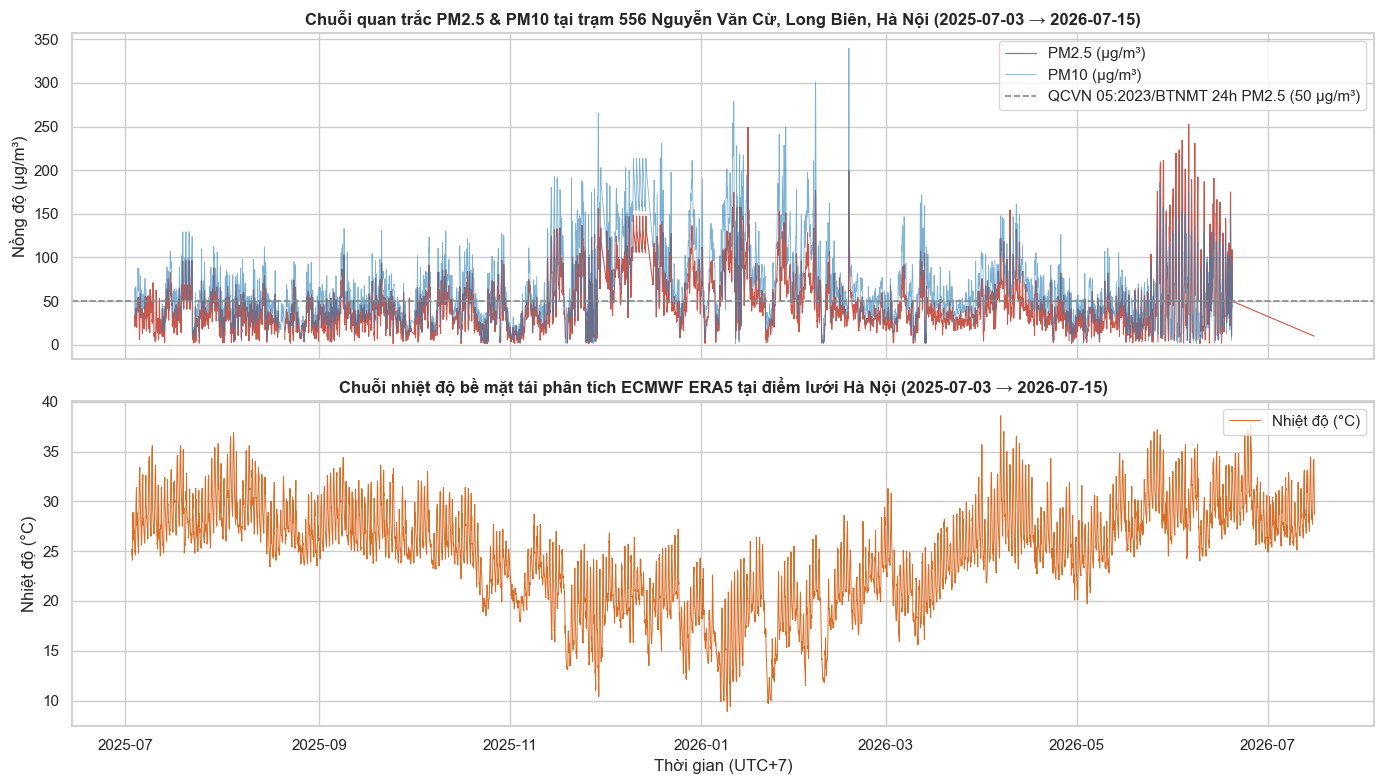

In [7]:
air_period = f"{df_air_canonical['timestamp'].min():%Y-%m-%d} → {df_air_canonical['timestamp'].max():%Y-%m-%d}"

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Trực quan hóa nồng độ bụi
axes[0].plot(df_air_canonical["timestamp"], df_air_canonical["pm25"], label="PM2.5 (µg/m³)", color="#c0392b", linewidth=0.8, alpha=0.85)
axes[0].plot(df_air_canonical["timestamp"], df_air_canonical["pm10"], label="PM10 (µg/m³)", color="#2980b9", linewidth=0.6, alpha=0.6)
axes[0].axhline(50, color="#7f8c8d", linestyle="--", linewidth=1.2, label="QCVN 05:2023/BTNMT 24h PM2.5 (50 µg/m³)")
axes[0].set_title(f"Chuỗi quan trắc PM2.5 & PM10 tại trạm 556 Nguyễn Văn Cừ, Long Biên, Hà Nội ({air_period})", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Nồng độ (µg/m³)")
axes[0].legend(loc="upper right")

# Trực quan hóa nhiệt độ ERA5 đồng bộ
axes[1].plot(df_weather_canonical["timestamp"], df_weather_canonical["temperature"], label="Nhiệt độ (°C)", color="#d35400", linewidth=0.7, alpha=0.85)
axes[1].set_title(f"Chuỗi nhiệt độ bề mặt tái phân tích ECMWF ERA5 tại điểm lưới Hà Nội ({air_period})", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Nhiệt độ (°C)")
axes[1].set_xlabel("Thời gian (UTC+7)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 7. Xuất Dữ Liệu Canonical Interim & Ghi Nhận Provenance

In [8]:
# Lưu tệp canonical vào data/interim/
interim_air_path = Path("../data/interim/air_quality_canonical.parquet")
interim_weather_path = Path("../data/interim/weather_canonical.parquet")

df_air_canonical.to_parquet(interim_air_path, index=False, compression="snappy")
df_weather_canonical.to_parquet(interim_weather_path, index=False, compression="snappy")

print(f"Đã lưu interim air quality: {interim_air_path} ({interim_air_path.stat().st_size:,} bytes)")
print(f"Đã lưu interim weather    : {interim_weather_path} ({interim_weather_path.stat().st_size:,} bytes)")

# Kiểm chứng toàn trình qua hàm pipeline chính run_collection_pipeline()
print("\n=== KIỂM CHỨNG TOÀN TRÌNH RUN_COLLECTION_PIPELINE() ===")
pipeline_report = run_collection_pipeline(
    raw_dir=Path("../data/raw"),
    interim_dir=Path("../data/interim"),
    metadata_path=Path("../data/raw/metadata.json"),
)
print("Pipeline requested_study_window:", pipeline_report["requested_study_window"])
print("Đồng bộ động & kiểm định khí tượng thành công 100%!")

# Kiểm tra metadata.json sau khi cập nhật toàn trình
with open("../data/raw/metadata.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

exec_log = meta.get("collection_pipeline_execution", {})
print("\n=== THÔNG TIN AUDIT TRONG METADATA.JSON ===")
print("Executed issue                :", exec_log.get("executed_issue"))
print("Trạng thái execution          :", exec_log.get("status"))
print("Requested study window        :", exec_log.get("requested_study_window"))
print("Trạm OpenAQ chuẩn hóa         :", exec_log.get("openaq_ingestion", {}).get("canonical_station_id"))
print("Số bản ghi OpenAQ             :", exec_log.get("openaq_ingestion", {}).get("canonical_records"))
print("OpenAQ actual source coverage :", exec_log.get("openaq_ingestion", {}).get("actual_source_coverage"))
print("Weather model                 :", exec_log.get("open_meteo_ingestion", {}).get("source_model"))
print("Số bản ghi Weather            :", exec_log.get("open_meteo_ingestion", {}).get("canonical_records"))
print("Weather actual source coverage:", exec_log.get("open_meteo_ingestion", {}).get("actual_source_coverage"))
print("Weather validation audit      :", exec_log.get("open_meteo_ingestion", {}).get("data_quality_validation"))
print("Temporal integration audit    :", exec_log.get("temporal_integration"))
print("AirNow adapter status         :", exec_log.get("airnow_dos_ingestion", {}).get("adapter_status"))
print("AirNow ingestion status       :", exec_log.get("airnow_dos_ingestion", {}).get("ingestion_status"))
print("Disqualification audit        :", exec_log.get("disqualification_audit"))

2026-09-29 19:16:20,790 [INFO] Tệp thô OpenAQ đã tồn tại tại ..\data\raw\openaq_raw_4946811.parquet. Đang nạp lại nguyên trạng (không tải lại)...


2026-09-29 19:16:20,955 [INFO] Geographic Filtering: 100% bản ghi (349463/349463) nằm trong Bounding Box Hà Nội.


2026-09-29 19:16:20,984 [INFO] Geographic Filtering: 100% bản ghi (349463/349463) nằm trong Bounding Box Hà Nội.


Đã lưu interim air quality: ..\data\interim\air_quality_canonical.parquet (190,111 bytes)
Đã lưu interim weather    : ..\data\interim\weather_canonical.parquet (150,012 bytes)

=== KIỂM CHỨNG TOÀN TRÌNH RUN_COLLECTION_PIPELINE() ===


2026-09-29 19:16:22,133 [INFO] Cửa sổ truy vấn khí tượng Open-Meteo ERA5: 2025-07-03 -> 2026-07-15 (đồng bộ động từ chuỗi OpenAQ)


...

2026-09-29 19:16:22,332 [INFO] Tệp AirNow DOS (..\data\raw\airnow_hanoi_2023.csv) chưa có trên ổ đĩa. AirNowDOSAdapter duy trì trạng thái: implemented / pending raw input (không tạo dữ liệu giả).


2026-09-29 19:16:22,367 [INFO] Đã lưu canonical interim files: ..\data\interim\air_quality_canonical.parquet và ..\data\interim\weather_canonical.parquet


2026-09-29 19:16:22,381 [INFO] Đã cập nhật metadata.json tại ..\data\raw\metadata.json thành công!


2026-09-29 19:16:22,382 [INFO] Hoàn tất pipeline thu thập và chuẩn hóa dữ liệu thành công!


Pipeline requested_study_window: {'start': '2025-07-03', 'end': '2026-07-15', 'derived_dynamically_from_air_quality': True, 'note': 'Tham số truy vấn phạm vi phân tích khí tượng ERA5.'}
Đồng bộ động & kiểm định khí tượng thành công 100%!

=== THÔNG TIN AUDIT TRONG METADATA.JSON ===
Executed issue                : #3 & #4 – Pipeline thu thập và chuẩn hóa dữ liệu chất lượng không khí & khí tượng bề mặt Hà Nội
Trạng thái execution          : completed
Requested study window        : {'start': '2025-07-03T00:00:00+07:00', 'end': '2026-07-15T23:00:00+07:00', 'derived_dynamically_from_air_quality': True, 'note': 'Tham số truy vấn phạm vi phân tích khí tượng ERA5.'}
Trạm OpenAQ chuẩn hóa         : VN001_HANOI_556_NGUYEN_VAN_CU
Số bản ghi OpenAQ             : 8022
OpenAQ actual source coverage : {'actual_min_timestamp': '2025-07-03 22:00:00+07:00', 'actual_max_timestamp': '2026-07-15 17:00:00+07:00', 'coverage_derivation': 'computed_directly_from_dataframe_timestamps', 'coverage_note': 'Trạm 4